In [1]:
from typing import Annotated
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.prebuilt import ToolNode, tools_condition
import requests
import os
from langchain_openai import ChatOpenAI
from typing import TypedDict


#### set up LangSmith!
https://langsmith.com

In [15]:
load_dotenv(override=True)

True

In [ ]:
from langchain_community.utilities import GoogleSerperAPIWrapper

serper = GoogleSerperAPIWrapper()
serper.run("What is the capital of France?")

'Paris'

### LangChain wrapper class for converting functions into Tools

In [12]:
from langchain_core.tools import Tool

tool_search =Tool(
        name="search",
        func=serper.run,
        description="Useful for when you need more information from an online search"
    )



### Now we can try out the tool the langchain way

In [13]:
tool_search.invoke("What is the capital of France?")

'Paris'

### Back to the Graph from yesterday

One small change - using TypedDict instead of BaseModel for the State object

When we implement tools, we always need to make 2 changes to the code:

1. Changes to provide the tools to OpenAI in json when we make the call

2. Changes to handle the results back: look for the model staying that the finish_reason=="tool_calls" and then retrieve the call, run the function, provide the results.

In [16]:
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"

def push(text: str):
    """Send a push notification to the user"""
    requests.post(pushover_url, data = {"token": pushover_token, "user": pushover_user, "message": text})

In [17]:
tool_push = Tool(
        name="send_push_notification",
        func=push,
        description="useful for when you want to send a push notification"
    )

In [18]:
tools = [tool_search, tool_push]

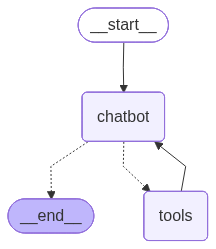

In [21]:
# Step 1: Define the State object
class State(TypedDict):
    messages: Annotated[list, add_messages]

# Step 2: Start the Graph Builder with this State class
graph_builder = StateGraph(State)

# This is different:
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

# Step 3: Create a Node
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]} #handles the request to the llm and packaging the tools in json

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools)) #handles what happens if there is a tool request, it unbundles the request and actual calling of the tool function

# Step 4: Create Edges
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools") #calls tools only if tool is present
# Any time a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# Step 5: Compile the Graph
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]})
    return result["messages"][-1].content


gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.


## It's time to add Memory!

### BUT WAIT!

We have this whole Graph maintaining the state and appending to the state.

Why isn't this handling memory?

### This is a crucial point for understanding LangGraph

> A super-step can be considered a single iteration over the graph nodes. Nodes that run in parallel are part of the same super-step, while nodes that run sequentially belong to separate super-steps.


One "Super-Step" of the graph represents one invocation of passing messages between agents.

In idomatic LangGraph, you call invoke to run your graph for each super-step; for each interaction.

The reducer handles state updates automatically within one super-step, but not between them.

That is what checkpointing achieves.

In [24]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

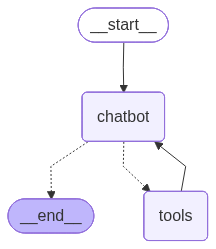

In [25]:
# Steps 1 and 2
graph_builder = StateGraph(State)


# Step 3
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# Step 5
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

##### Eventhough if you relaunch the gradio it has prev memory saved! 
##### To refresh with no memory, ned to rerun the above memory object created.

In [ ]:
config = {"configurable": {"thread_id": "1"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='Hi i am pradeep', additional_kwargs={}, response_metadata={}, id='19b615f3-69f7-46fe-a96d-e8857ec82d8f')]}
{'messages': [HumanMessage(content='Hi i am pradeep', additional_kwargs={}, response_metadata={}, id='19b615f3-69f7-46fe-a96d-e8857ec82d8f'), AIMessage(content='Hello Pradeep! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 94, 'total_tokens': 107, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c2f5782bd4', 'id': 'chatcmpl-DlusWJCWJjMAvc3YBgTwOx3Aw1tYG', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e82e3-cea7-7d73-889f-f39234f08571-0', tool_calls=[], invalid_tool

In [30]:
graph.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi i am pradeep', additional_kwargs={}, response_metadata={}, id='19b615f3-69f7-46fe-a96d-e8857ec82d8f'), AIMessage(content='Hello Pradeep! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 94, 'total_tokens': 107, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c2f5782bd4', 'id': 'chatcmpl-DlusWJCWJjMAvc3YBgTwOx3Aw1tYG', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e82e3-cea7-7d73-889f-f39234f08571-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 94, 'output_tokens': 13, 'total_tokens': 107, 'input_token_details': {'audio': 

In [31]:
# Most recent first

list(graph.get_state_history(config))

[StateSnapshot(values={'messages': [HumanMessage(content='Hi i am pradeep', additional_kwargs={}, response_metadata={}, id='19b615f3-69f7-46fe-a96d-e8857ec82d8f'), AIMessage(content='Hello Pradeep! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 94, 'total_tokens': 107, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c2f5782bd4', 'id': 'chatcmpl-DlusWJCWJjMAvc3YBgTwOx3Aw1tYG', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e82e3-cea7-7d73-889f-f39234f08571-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 94, 'output_tokens': 13, 'total_tokens': 107, 'input_token_details': {'audio':

### LangGraph gives tools to set the state back to a prior point in time, to branch off:

```
config = {"configurable": {"thread_id": "1", "checkpoint_id": ...}}
graph.invoke(None, config=config)
```

And this to build stable systems that can be recovered and rerun from any prior checkpoint.

### And now let's store in SQL

### And this is the power of LangGraph.

In [49]:
# Upgrade all checkpoint packages together to avoid version mismatches (e.g. DeltaChannelHistory import errors)
!pip install -q -U langgraph langgraph-checkpoint langgraph-checkpoint-sqlite

# pip upgrades files on disk but Jupyter keeps old modules in memory — clear them before importing SqliteSaver
import sys
for _name in list(sys.modules):
    if _name == "langgraph" or _name.startswith("langgraph."):
        del sys.modules[_name]

In [ ]:
!pip show langgraph
!pip show langgraph-checkpoint
!pip show langgraph-checkpoint-sqlite

In [ ]:
# Run the next cell to create sql_memory and compile the graph with SQLite checkpointing.


In [ ]:
# Re-import LangGraph so compile() uses the same BaseCheckpointSaver class as SqliteSaver.
# (StateGraph from earlier cells was loaded before the pip upgrade cleared sys.modules.)
import sqlite3
from langgraph.graph import StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.sqlite import SqliteSaver

db_path = "memory.db"
conn = sqlite3.connect(db_path, check_same_thread=False)
sql_memory = SqliteSaver(conn)

# Steps 1 and 2
graph_builder = StateGraph(State)

# Step 3
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4
graph_builder.add_conditional_edges("chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# Step 5
graph = graph_builder.compile(checkpointer=sql_memory)
display(Image(graph.get_graph().draw_mermaid_png()))
